# Conditional workflow 

In [32]:
from langgraph.graph import StateGraph,START,END
from langchain_mistralai import ChatMistralAI
import operator 
from dotenv import load_dotenv
from typing import TypedDict, Literal,Annotated
from pydantic import Field, BaseModel
load_dotenv()

True

In [17]:
class formated_output(BaseModel):
    sentiment : Literal['Negative','Positive'] = Field(description="Based on review analyse and return sentiment") 
    
class Diagnosis_scheme(BaseModel):
    issue_type : Literal['UI',"Performance","Hardware","Software"] = Field(description="Based on the review classify the issue in the review.")
    tone : Literal["polite","angry","disappointed"] = Field(description="Based on the review classify the tone of review")
    urgency : Literal["low","medium","high"] = Field(description="Based on the review classifiy the urgency.")


In [18]:
class SentimentState(TypedDict):
    review : str 
    diagnosis : dict
    sentiment : Literal['Negative',"Positive"]
    final_review = str 

model = ChatMistralAI(
    model = "mistral-small-latest",
    temperature = 0.7
)

model_1 = model.with_structured_output(formated_output)
model_2 = model.with_structured_output(Diagnosis_scheme)

In [19]:
# Helper Functions 

def Analyse_Sentiment(state : SentimentState) -> SentimentState:
    prompt = f"for the following review analyse its sentiment REVIEW : {state['review']}"
    sentiment = model_1.invoke(prompt).sentiment
    return {"sentiment":sentiment} 

def Check_condition(state : SentimentState) -> Literal["Positive_sentiment","Diagnosis_review"]:

    if state['sentiment'] == "Positive":
        return "Positive_sentiment"
    else : 
        return "Diagnosis_review"
    

def Diagnosis_review(state : SentimentState) -> SentimentState:
    prompt = f"Analyse this Negative Review : {state['review']} and return issue_type, tone and urgency."
    output = model_2.invoke(prompt)
    return {"diagnosis" : {"issue_type":output.issue_type,"tone":output.tone,"urgency":output.urgency}}

def Positive_sentiment(state : SentimentState) -> SentimentState:
    prompt = f"analyse the following Postive review : {state['review']} and based on it reply to user."

    final_review = model.invoke(prompt).content

    return {"final_review":final_review}

def Negative_sentiment(state : SentimentState) -> SentimentState:
    prompt =  f"Based on {state['diagnosis'] } generate a reply to user."
    final_review = model.invoke(prompt).content
    return {"final_review":final_review}

    

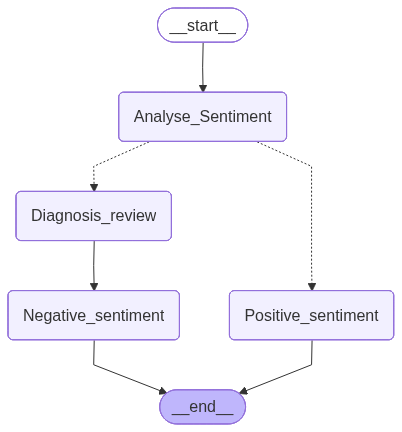

In [20]:
Graph = StateGraph(SentimentState)

# Creating nodes 
Graph.add_node("Analyse_Sentiment",Analyse_Sentiment)
Graph.add_node("Diagnosis_review",Diagnosis_review)
Graph.add_node("Negative_sentiment",Negative_sentiment)
Graph.add_node("Positive_sentiment",Positive_sentiment)

# Creating Edges 
Graph.add_edge(START,"Analyse_Sentiment")
Graph.add_conditional_edges("Analyse_Sentiment",Check_condition)
Graph.add_edge("Diagnosis_review","Negative_sentiment")
Graph.add_edge("Positive_sentiment",END)
Graph.add_edge("Negative_sentiment",END)

# Compile Graph
workflow = Graph.compile()
workflow


In [22]:
inital_state = {
    "review" : "the Samsung s24 is very bad, bad display, bad performance, high cost."
}

response = workflow.invoke(inital_state)
response

{'review': 'the Samsung s24 is very bad, bad display, bad performance, high cost.',
 'diagnosis': {'issue_type': 'Hardware', 'tone': 'angry', 'urgency': 'high'},
 'sentiment': 'Negative'}

# Iterative Workflow

In [50]:
generator_model = ChatMistralAI(model = "mistral-large-latest")
evaluation_model = ChatMistralAI(model = "mistral-small-latest")
optimizer_model = ChatMistralAI(model = "mistral-small-latest")

In [51]:
class Tweet_State(TypedDict):
    topic : str 
    tweet : str 
    evaluation : Literal["Approved","Needs_Improvement"]
    feedback : str 
    iteration : int 
    max_iteration : int 
    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

class Output_format(BaseModel):
    evaluation : Literal["Approved","Needs_Improvement"] = Field(description="analyse the provided tweet and return evaluation")
    feedback: str = Field(..., description="feedback for the tweet.")
    
evaluation_model = evaluation_model.with_structured_output(Output_format)

In [59]:
# Helper functions 
def generate_tweet(state : Tweet_State) -> Tweet_State:
    prompt = f"""
    Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
    Rules:
    - Do NOT use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple, day to day english
    """
    tweet = generator_model.invoke(prompt).content

    return {'tweet': tweet, 'tweet_history': [tweet]}

def evaluate_tweet(state : Tweet_State) -> Tweet_State:
    prompt = f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet Strictly:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """
    response = evaluation_model.invoke(prompt)
    return {"evaluation":response.evaluation, "feedback":response.feedback, "feedback_history":[response.feedback]}

def optimizer_tweet(state : Tweet_State) -> Tweet_State:
    prompt = f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
    """
    response = optimizer_model.invoke(prompt).content 
    iteration = state['iteration'] 

    return {"tweet":response,"iteration":iteration,"tweet_history":[response]} 


def check_condition(state : Tweet_State) -> Tweet_State:
    if state['evaluation'] == "Approved" or state['iteration'] >= state['max_iteration']:
        return "Approved"
    else : 
        return "Needs_Improvement"

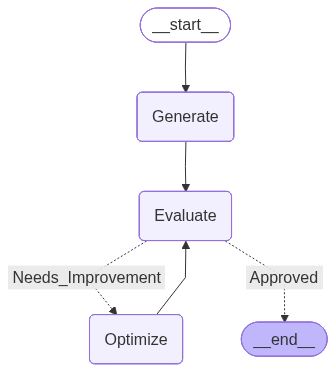

In [60]:
graph = StateGraph(Tweet_State)

# creating nodes 
graph.add_node("Generate",generate_tweet)
graph.add_node("Evaluate",evaluate_tweet)
graph.add_node("Optimize",optimizer_tweet)

graph.add_edge(START,"Generate")
graph.add_edge("Generate","Evaluate")

graph.add_conditional_edges("Evaluate",check_condition,{"Approved":END,"Needs_Improvement":"Optimize"})
graph.add_edge("Optimize","Evaluate")

workflow = graph.compile()
workflow

In [61]:
inital_state = {
    "topic" : "Chandler Bing"
}
response = workflow.invoke(inital_state)
response

{'topic': 'Chandler Bing',
 'tweet': '"Chandler Bing’s idea of a ‘scary story’ is ‘what if we ran out of sarcasm and had to feel things?’ Meanwhile, the rest of us are out here crying over a sad commercial."',
 'evaluation': 'Approved',
 'feedback': 'This tweet excels in originality, humor, and punchiness. It presents a fresh and witty observation about Chandler Bing’s character from the popular TV show *Friends*, juxtaposing his sarcastic nature with the relatability of crying over a sad commercial. The humor is clever, universally appealing to fans of the show, and likely to elicit genuine chuckles or smiles. The tweet is concise, well within the 280-character limit, and avoids common pitfalls like question-answer format or weak closing lines. Its format is clean, and it avoids being a traditional setup-punchline joke. Additionally, the tweet has strong virality potential, as it taps into nostalgia and shared cultural references, making it highly shareable and retweet-worthy among fa